# Create a wavelength lookup table for ESTIA

This notebook recreates the wavelength lookup table that is used to compute wavelength from time-of-arrival for the ESTIA instrument.

To reproduce the lookup table you will need to provide some instrument parameters like pulse stride and chopper position.

In [1]:
%matplotlib ipympl
import scipp as sc
import scippnexus as snx
import scipp.constants
from ess.reduce import unwrap
from ess.reduce.nexus.types import AnyRun, Position
from scippneutron.chopper import DiskChopper

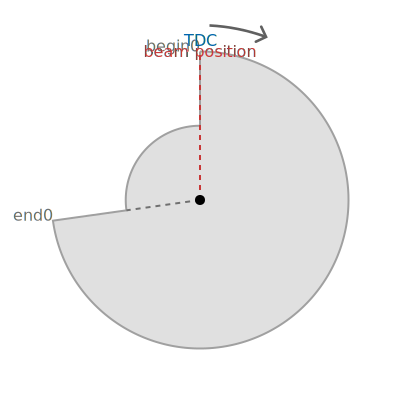

In [2]:
# Parameters from the ESTIA McStas file:
# https://git.esss.dk/dmsc-instrumentmodels/estia/-/blob/main/mcstas-master/simulation/Estia_baseline.instr
min_wavelength = sc.scalar(3.75, unit='angstrom')
chopper_position = sc.scalar(10.895, unit='m')
max_velocity = (sc.constants.h / sc.constants.m_n / min_wavelength).to(unit='m/s')
delay = chopper_position / max_velocity
pulse_stride = 1
frequency = -sc.scalar(14., unit='Hz') / pulse_stride

disk_choppers = {
    "fc": DiskChopper(
        frequency=frequency,
        beam_position=sc.scalar(0.0, unit="deg"),
        phase=delay * frequency * sc.scalar(360, unit="deg"),
        axle_position=sc.vector(value=[0, 0., chopper_position.value], unit=chopper_position.unit),
        slit_begin=sc.array(
            dims=["cutout"],
            values=[
                0.
            ],
            unit="deg",
        ),
        slit_end=sc.array(
            dims=["cutout"],
            values=[
                98.
            ],
            unit="deg",
        ),
    ),
}
disk_choppers['fc']

In [3]:
wf = unwrap.LookupTableWorkflow()

wf[unwrap.LtotalRange[AnyRun, snx.NXdetector]] = sc.scalar(35., unit="m"), sc.scalar(45.0, unit="m")
wf[unwrap.NumberOfSimulatedNeutrons] = 1_000_000
wf[Position[snx.NXsource, AnyRun]] = sc.vector([0, 0, 0], unit='m')
wf[unwrap.DiskChoppers[AnyRun]] = disk_choppers
wf[unwrap.DistanceResolution] = sc.scalar(0.05, unit="m")
wf[unwrap.TimeResolution] = 1.0 / sc.scalar(14.0, unit="Hz") / 200
wf[unwrap.PulsePeriod] = 1.0 / sc.scalar(14.0, unit="Hz")
wf[unwrap.PulseStrideOffset] = 0

In [4]:
%%time
table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])
table

CPU times: user 3.82 s, sys: 1.17 s, total: 4.99 s
Wall time: 1.71 s


LookupTable(array=<scipp.DataArray>
Dimensions: Sizes[distance:205, event_time_offset:201, ]
Coordinates:
* distance                  float64              [m]  (distance)  [34.9, 34.95, ..., 45.05, 45.1]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 357.143, ..., 71071.4, 71428.6]
Data:
                            float64             [Å]  (distance, event_time_offset)  [7.88564, 7.92456, ..., 6.08057, 6.10842]  [0.00970029, 0.0113666, ..., 0.00620075, 0.00583035]

, pulse_period=<scipp.Variable> ()    float64            [µs]  71428.6, pulse_stride=1, distance_resolution=<scipp.Variable> ()    float64              [m]  0.05, time_resolution=<scipp.Variable> ()    float64            [µs]  357.143, choppers=DataGroup(sizes={'cutout': 1}, keys=[
    fc: DataGroup(8, {'cutout': 1}),
]))

In [5]:
# This is what the relationship between time-of-arrival and wavelength looks like at 40m (at the detector).
table.array['distance', 100].plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [6]:
(sc.stddevs(table.array)/sc.values(table.array)).plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [7]:
table.save_hdf5(f'estia-lookup-table-pulse-stride-{pulse_stride}.h5')

Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.
